# 网格世界 Actor–Critic：训练并验证最优策略

默认配置保留原实验地图、`-10 / 0 / +10` 奖励和 `gamma=0.9`。禁止格实际是可进入的惩罚格。
目标格到达即终止，后续价值为 0，reset 不再抽到目标格。

使用 one-hot 状态和独立线性 Actor、Critic，即表格参数化的神经网络 AC。
默认每次更新从全部 23 个非终止状态各采样 32 个当前策略动作，共 736 次环境交互。
这是均衡起点的一步 AC；不会让不终止的轨迹垄断训练数据。它不是原来的单轨迹 MLP 实验，更新次数不能直接等同于旧实验的环境步数。

**动态规划仅用于评估与停止判定，不向 Actor 或 Critic 提供训练标签。**

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

cwd = Path.cwd().resolve()
workspace = next(p for p in (cwd, *cwd.parents) if (p / "code" / "AC").is_dir())
sys.path.insert(0, str(workspace / "code" / "AC"))
from config import config
from train import train, save_run
from evaluate import evaluate, optimal_reference
from visualize import plot_policy, plot_training_curve, plot_convergence


## 参数集中配置（修改下面一个单元格即可）

环境、训练、学习率衰减、验收精度、运行设置及输出绘图选项全部在下面显式设置。
默认值与已验证收敛的实验相同。修改后从本单元格向下运行，会重新初始化并训练模型。
修改 Python 模块文件后请重启内核并全部运行。

`batch_size` 是每个非终止状态的动作采样数；每次更新总样本数由地图自动计算。
one-hot 输入维度由地图大小自动计算，动作固定为上、右、下、左、停留；当前线性网络没有隐藏层参数。
高级数值容限用于验收精度，调大容限会放宽验收，不代表模型实际变得更优。


In [2]:
# ==================== 环境与奖励 ====================
cfg = config(
    row_num=5,
    col_num=5,
    # 0=普通格，1=可进入的惩罚格，2=终止目标
    grid=[
        [0, 0, 0, 0, 1],
        [0, 1, 1, 0, 2],
        [1, 0, 1, 0, 0],
        [0, 1, 2, 1, 0],
        [0, 1, 0, 0, 0],
    ],
    reward={
        "boundary": -10,        # 越界奖励
        "forbidden": -10,       # 进入惩罚格的奖励
        "target": 10,           # 到达目标的奖励
        "blank": 0,             # 进入普通格或在普通格停留的奖励
    },

    # ==================== 训练参数 ====================
    gamma=0.9,                 # 折扣率，0 <= gamma < 1
    lr=0.03,                   # Actor 初始学习率
    critic_lr=0.03,            # Critic 初始学习率
    batch_size=32,            # 每个非终止状态、每次更新的采样数
    train_iteration=12000,    # 最大更新次数，连续达标可提前停止
    entropy_coef=0.02,        # 初始熵正则系数
    entropy_decay_steps=2000, # 熵系数线性下降至 0 的更新数
    max_grad_norm=1.0,        # Actor/Critic 各自的梯度裁剪阈值
    reward_scale=None,        # None=自动奖励尺度；也可指定正数

    # 实际学习率 = 初始学习率 * max(min_lr_ratio, 1-update/lr_decay_steps)
    lr_decay_steps=6000,      # 学习率线性衰减的时间尺度
    min_lr_ratio=0.1,         # 最低学习率占初始值的比例；1 表示不衰减

    # ==================== 收敛验收 ====================
    eval_interval=100,        # 每多少次更新评估一次
    patience=5,               # 连续通过多少次评估才停止
    greedy_tolerance=1e-8,    # 贪心策略最大价值误差须小于此值
    policy_tolerance=0.05,    # 随机策略最大价值误差容限（原奖励单位）
    critic_tolerance=0.1,     # Critic 相对当前随机策略价值的误差容限

    # ==================== 高级数值精度 ====================
    value_iteration_tolerance=1e-12, # 最优基准值迭代停止阈值
    value_iteration_max_steps=10000, # 最优基准值迭代次数上限
    optimal_action_tolerance=1e-9,   # 判断并列最优动作的绝对容限

    # ==================== 随机性与计算设备 ====================
    seed=123456,
    device="cpu",                  # cpu / cuda / auto
    num_threads=1,                  # PyTorch CPU 线程数
    deterministic_algorithms=True,  # 使用确定性算法
)

# ==================== 输出与绘图 ====================
output_dir = workspace / "output" / "ac_converged"  # 对照实验可修改最后一级目录
verbose = True                # 输出训练评估日志
save_artifacts = True         # 保存模型、完整历史与逐状态诊断
save_figures = True           # 保存图片
show_figures = True           # 在 notebook 中显示图片
smoothing_window = 100        # 损失/熵曲线移动平均窗口（更新数）
figure_dpi = 180               # 保存图片的分辨率
value_decimals = 5            # 打印价值矩阵的小数位数

print(json.dumps(cfg.to_dict(), indent=2))
print(f"Samples per update: {np.count_nonzero(cfg.env.grid != 2) * cfg.rl.batch_size}")
print(f"Output directory: {output_dir}")


{
  "env": {
    "row_num": 5,
    "col_num": 5,
    "reward": {
      "boundary": -10,
      "forbidden": -10,
      "target": 10,
      "blank": 0
    },
    "grid": [
      [
        0,
        0,
        0,
        0,
        1
      ],
      [
        0,
        1,
        1,
        0,
        2
      ],
      [
        1,
        0,
        1,
        0,
        0
      ],
      [
        0,
        1,
        2,
        1,
        0
      ],
      [
        0,
        1,
        0,
        0,
        0
      ]
    ]
  },
  "rl": {
    "gamma": 0.9,
    "lr": 0.03,
    "critic_lr": 0.03,
    "batch_size": 32,
    "train_iteration": 12000,
    "device": "cpu",
    "entropy_coef": 0.02,
    "entropy_decay_steps": 2000,
    "max_grad_norm": 1.0,
    "eval_interval": 100,
    "patience": 5,
    "policy_tolerance": 0.05,
    "critic_tolerance": 0.1,
    "lr_decay_steps": 6000,
    "min_lr_ratio": 0.1,
    "greedy_tolerance": 1e-08,
    "value_iteration_tolerance": 1e-12,
    "value_i

## 实际训练

优势和 Critic 的 TD 误差统一除以配置的奖励尺度；环境奖励及评估回报保持原单位。
熵系数与学习率按照上面的配置衰减，Actor 和 Critic 使用独立优化器。
训练曲线的 loss 为归一化量。达到最大更新数仍未通过验收会报错，不会宣称收敛。


In [3]:
runner, history, evaluations, result = train(cfg, verbose=verbose)
if save_artifacts:
    save_run(output_dir, cfg, runner, history, evaluations, result)
    settings = dict(verbose=verbose, save_artifacts=save_artifacts,
                    save_figures=save_figures, show_figures=show_figures,
                    smoothing_window=smoothing_window, figure_dpi=figure_dpi,
                    value_decimals=value_decimals, output_dir=str(output_dir))
    (output_dir / "notebook_settings.json").write_text(
        json.dumps(settings, indent=2), encoding="utf-8")
assert result["converged"], "未满足收敛条件，请检查训练日志。"
assert all(record["passed"] for record in evaluations[-cfg.rl.patience:])
print(f"Converged after {result['updates']} updates / {result['environment_samples']} environment samples")
print(json.dumps(result["metrics"], indent=2))


update=  100 optimal=95.7% greedy_gap=1.000000 sampled_policy_gap=5.44174 critic_error=8.97935 stable=0/5


update=  200 optimal=91.3% greedy_gap=1.000000 sampled_policy_gap=1.33050 critic_error=0.29100 stable=0/5


update=  300 optimal=91.3% greedy_gap=1.000000 sampled_policy_gap=1.17910 critic_error=0.37898 stable=0/5


update=  400 optimal=95.7% greedy_gap=1.000000 sampled_policy_gap=1.11074 critic_error=0.28440 stable=0/5


update=  500 optimal=95.7% greedy_gap=1.000000 sampled_policy_gap=1.07140 critic_error=0.28333 stable=0/5


...

update= 5200 optimal=100.0% greedy_gap=0.000000 sampled_policy_gap=0.01040 critic_error=0.05329 stable=2/5


update= 5300 optimal=100.0% greedy_gap=0.000000 sampled_policy_gap=0.01020 critic_error=0.06854 stable=3/5


update= 5400 optimal=100.0% greedy_gap=0.000000 sampled_policy_gap=0.01005 critic_error=0.06342 stable=4/5


update= 5500 optimal=100.0% greedy_gap=0.000000 sampled_policy_gap=0.00985 critic_error=0.03953 stable=5/5


Converged after 5500 updates / 4048000 environment samples
{
  "optimal_action_fraction": 1.0,
  "greedy_max_gap": 1.7763568394002505e-15,
  "stochastic_max_gap": 0.009851777410156503,
  "critic_max_error": 0.03953411784970662,
  "greedy_mean_value": 7.4709265217391305,
  "stochastic_mean_value": 7.467131092367216,
  "optimal_mean_value": 7.4709265217391305,
  "min_optimal_action_mass": 0.9992067039307435
}


## 全状态精确评估与收敛曲线

通过解线性方程得到当前随机策略与贪心策略的真实折扣价值，不依赖短轨迹估算。
所有状态均纳入，包括惩罚格和最优行为是不终止的状态；目标格作为终止态单独处理。
收敛图包含每一个评估点、不做平滑。原始数据见 `evaluation_history.csv`。
图中误差面板采用对称对数坐标，零误差也保留。

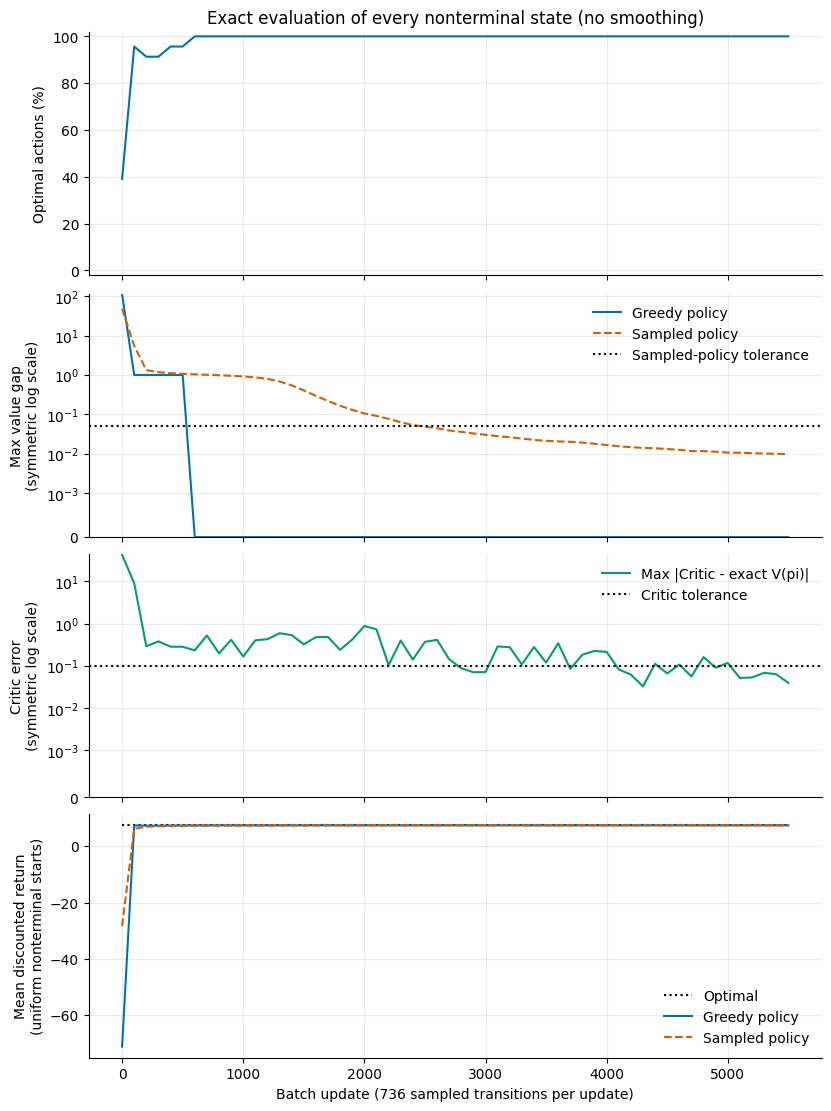

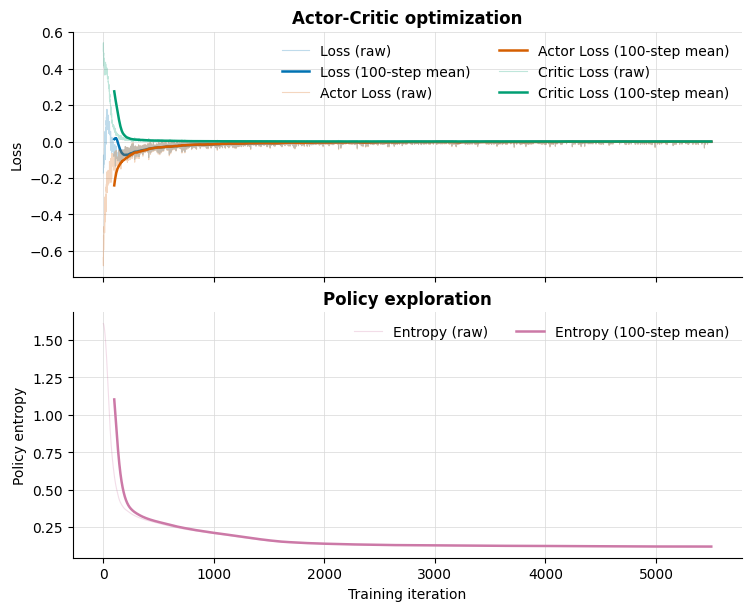

In [4]:
fig, axes = plot_convergence(
    evaluations, cfg,
    save_path=output_dir / "ac_convergence.png" if save_figures else None,
    show=False, dpi=figure_dpi,
)
if show_figures:
    display(fig)
plt.close(fig)

fig, axes = plot_training_curve(
    history,
    save_path=output_dir / "ac_training_metrics.png" if save_figures else None,
    show=False, smoothing_window=smoothing_window, dpi=figure_dpi,
)
if show_figures:
    display(fig)
plt.close(fig)


## 最终策略和 Critic

箭头表示最大概率动作，圆圈表示停留，数字是所选动作的概率。目标格不画动作箭头。
在默认地图与奖励下，第 3 行第 2 列、第 4 行第 1 列、第 5 行第 1 列的最优回报是 0：
离开这些区域至少需要一次 -10，而最终奖励只有 +10，折扣后不如无限期安全停留。
因此最优不等于所有起点都到达目标；这里没有偷偷更换奖励来提高成功率。

下方目标附近的捷径应被学到：`(5,3)` 向上，`(5,4)` 向左（坐标从 1 开始）。

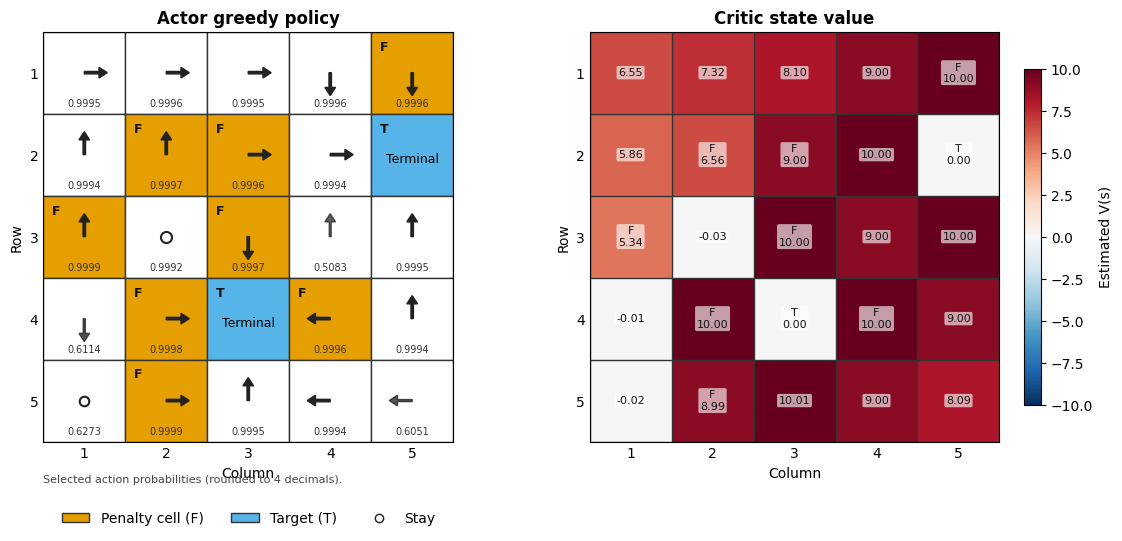

Greedy policy: 0=up, 1=right, 2=down, 3=left, 4=stay, -1=terminal
[[ 1  1  1  2  2]
 [ 0  0  1  1 -1]
 [ 0  4  2  0  0]
 [ 2  1 -1  3  0]
 [ 4  1  0  3  3]]
Optimal values:
[[ 6.561    7.29     8.1      9.      10.     ]
 [ 5.9049   6.561    9.      10.       0.     ]
 [ 5.31441  0.      10.       9.      10.     ]
 [ 0.      10.       0.      10.       9.     ]
 [ 0.       9.      10.       9.       8.1    ]]
Exact greedy-policy values:
[[ 6.561    7.29     8.1      9.      10.     ]
 [ 5.9049   6.561    9.      10.       0.     ]
 [ 5.31441  0.      10.       9.      10.     ]
 [ 0.      10.       0.      10.       9.     ]
 [ 0.       9.      10.       9.       8.1    ]]
Results saved to D:\My Knowledge\AI algorithm&architecture\Reinforcement-Learning\output\ac_converged


In [5]:
fig, axes, policy, diagnostics = plot_policy(
    runner, cfg,
    save_path=output_dir / "ac_policy_and_value.png" if save_figures else None,
    show=False, dpi=figure_dpi,
)
if show_figures:
    display(fig)
plt.close(fig)
reference = optimal_reference(cfg)
terminal = cfg.env.grid == 2
shown_policy = policy.copy()
shown_policy[terminal] = -1
print("Greedy policy: 0=up, 1=right, 2=down, 3=left, 4=stay, -1=terminal")
print(shown_policy)
print("Optimal values:")
print(reference["values"].reshape(cfg.env.grid.shape).round(value_decimals))
print("Exact greedy-policy values:")
print(result["greedy_values"].reshape(cfg.env.grid.shape).round(value_decimals))
# 适用于任意配置地图，不再固定检查原地图中的某两个坐标。
assert np.max(np.abs(result["greedy_values"] - reference["values"])) < cfg.rl.greedy_tolerance
if save_artifacts or save_figures:
    print(f"Results saved to {output_dir}")


## 复现与限制

可从工作区运行 `python code/AC/train.py`；另用 `python code/AC/validate_seeds.py` 验证种子 1、2、3、42。
环境、精确价值、并列最优与终止掩码测试：`python code/AC/test_ac.py`。
当前结果证明此固定有限网格上的贪心最优性，不是对任意地图或连续状态任务的收敛保证。
旧代码、旧 notebook 和旧图片保存在 `output/ac_before_changes`。